In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from encoder_decoder import*
import matplotlib.pyplot as plt

# Check vocab and define encoding/decoding functions (from int to char and viceversa)
# Define the vocab and vocab_size

In [2]:
# first import the little dictionary frol it_es_cognates.txt

italian_words = []
spanish_words = []

with open("it_es_cognates.txt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        it, es = line.split(";") # words separated by ;
        italian_words.append(it.lower())
        spanish_words.append(es.lower())

# check the number of words in the list of cognates
print(len(italian_words), "pairs")
print(italian_words[:5], spanish_words[:5])

# find all characters appearing in the list of cognates
all_chars = set()
for word in spanish_words + italian_words:
    all_chars.update(word)
all_chars = sorted(all_chars)

# add the special caracters: pad, start of string, end of string, unknown
specials = ['<pad>', '<sos>', '<eos>', '<unk>']
vocab = specials + all_chars

# build the dictionaries, just use the enumeration of vocab to assign an integer to every character
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

# check the characters in the vocabulary, and its length
print("vocab: ", vocab)
print("vocab length:", len(vocab))

# test word size in the vocabulary (need to know the dimension of the words I am going to have in the model - by padding)
# I will add 2 or 3 just to be on the safe side for future additions to the dictionary, getting, say, to 20
print("Max length of spanish words: ", max(len(w) for w in spanish_words))
print("Max length of italian words: ", max(len(w) for w in italian_words))

def encode_source(word, max_len = 20):
    # input: no sos/eos needed
    ids = [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len] # use the char to int dictionary
    ids += [char_to_idx['<pad>']] * (max_len - len(ids)) # fill with '<pad>' until the prescribed length max_len
    return torch.tensor(ids)

def encode_target(word, max_len = 20):
    # output: needs sos/eos since decoder generates it step by step, they will replace two <pad> 
    ids = [char_to_idx['<sos>']] + [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len-2] + [char_to_idx['<eos>']]
    ids += [char_to_idx['<pad>']] * (max_len - len(ids))
    return torch.tensor(ids) 

def decode_source(ids):
    
    ids_numpy = ids.numpy()
    chars = []
    for i in ids_numpy:
        ch = idx_to_char[i] # use the integer to char dictionary
        if ch == '<pad>':
            break  # padding marks the end of real content
        chars.append(ch)
    return ''.join(chars)

# test
print(encode_source('castoro'))
print(decode_source(encode_source('castoro'))) 
print(decode_source(encode_source('è'))) # check unknown characters


# now test the embedding
vocab_size = len(char_to_idx)
d_model = 32 # needs to be large enough but does not have to be larger than number of characters - in fact for LLMs it is smaller than the number of tokens
embed = nn.Embedding(vocab_size, d_model, padding_idx=char_to_idx['<pad>'])

print(embed(encode_source('castoro')))

1330 pairs
['acqua', 'acque', 'aeroporti', 'aeroporto', 'affezionata'] ['agua', 'aguas', 'aeropuertos', 'aeropuerto', 'aficionada']
vocab:  ['<pad>', '<sos>', '<eos>', '<unk>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', 'à', 'á', 'é', 'í', 'ñ', 'ó', 'ù', 'ú']
vocab length: 36
Max length of spanish words:  15
Max length of italian words:  13
tensor([ 6,  4, 21, 22, 17, 20, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0])
castoro
<unk>
tensor([[-0.5710,  0.2797, -1.7350,  0.4467,  1.6076,  0.2248,  0.1058,  0.5708,
         -0.6707, -0.5470, -1.9505, -0.1519,  1.0266,  0.0477,  0.7419,  0.3297,
          0.8491,  1.3897, -0.5881, -1.4533, -1.9097,  0.9407, -0.1205, -0.4158,
         -0.3740,  0.0652,  0.5123, -0.2234,  0.7404, -1.1190, -1.7444, -0.2214],
        [-2.9866,  0.1527,  1.3491,  0.8371, -1.1778,  0.4734, -0.1179, -0.2900,
         -1.2602, -1.2139,  0.4788,  0.2420, -1.2262,  0.6599, 

# Various tests done while coding the class

In [3]:
# test if Encoder runs correctly

enco = Encoder(2, d_model = d_model, d_hidden = 4*d_model, dk = 8, dv = 8, h = 4)
pos_enco = PositionalEncodingModule(d_model=d_model)

encoded_word = pos_enco(enco(embed(encode_source('castoro')).unsqueeze(0)))
# print(encoded_word)

# ok

# test if Transformer runs correctly 

trafo = Transformer(n_layers = 3, d_model = d_model, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8)

print(trafo(encode_source("castoro").unsqueeze(0), encode_source("diga").unsqueeze(0)))
print(trafo.generate_sequence(encode_source("castoro").unsqueeze(0)))

tensor([[[ 0.4781, -0.1849, -0.6532, -0.5849, -0.3660, -0.3458,  0.1939,
           0.3628,  0.3515, -0.7043,  0.9720, -0.0821,  0.1467, -0.1871,
          -0.5286, -0.5225, -0.1830,  0.6158, -0.1257,  0.0222,  0.3428,
           0.5450, -1.1587,  0.3292, -0.2397, -0.3460, -0.0160,  0.3077,
          -0.5811,  0.9473, -0.7755, -0.2016,  0.8961, -0.2452, -0.4994,
          -0.3556],
         [ 0.1157,  0.0554, -0.4328, -0.4192, -0.1220, -0.7453, -0.0941,
           0.5923, -0.0456,  0.1054,  0.4746, -0.2229,  0.3930,  0.4135,
          -0.5615, -1.0464,  0.3000, -0.0636,  0.0045,  0.9407,  0.3540,
          -0.0167, -0.4097, -0.5946,  0.1522, -0.2778,  0.5451, -0.3035,
          -0.2085,  0.1324, -0.2427, -0.8785,  1.0263, -0.3679, -0.2063,
          -0.1860],
         [ 0.4268,  0.2730, -1.1013,  0.3464,  0.0280,  0.5259,  0.2609,
          -0.8751, -0.7872, -0.5830,  0.6479,  0.5534, -0.2694, -0.7998,
          -0.0350,  0.0795, -0.1521,  1.0486, -0.3416,  0.0432,  0.5385,
           

In [4]:
def count_parameters_by_module(model: nn.Module, trainable_only: bool = True) -> dict:
    """counts the number of parameters, in total and for every submodule"""
    counts = {}
    for name, module in model.named_children():
        if trainable_only:
            n = sum(p.numel() for p in module.parameters() if p.requires_grad)
        else:
            n = sum(p.numel() for p in module.parameters())
        counts[name] = n
    counts["TOTAL"] = sum(counts.values())
    return counts

count_parameters_by_module(trafo)

{'embed': 1152,
 'pos_encoding': 0,
 'encoder': 38112,
 'decoder': 50976,
 'exit_linear_projection': 1188,
 'criterion': 0,
 'TOTAL': 91428}

# Fit the model

In [5]:

# define and train two models, a lighter and a heabier one
trafo1 = Transformer(n_layers = 1, d_model = 16, n_heads = 1, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 2, dv = 2, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)
trafo2 = Transformer(n_layers = 4, d_model = 32, n_heads = 8, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)

# here weight_decya = 1e-2
trafo1_weight_decay = Transformer(n_layers = 1, d_model = 16, n_heads = 1, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 2, dv = 2, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200, use_weight_decay = True)
trafo2_weight_decay = Transformer(n_layers = 4, d_model = 32, n_heads = 8, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200, use_weight_decay = True)


print('trafo1')
print(trafo1.count_parameters_by_module())
print('trafo2')
print(trafo2.count_parameters_by_module())

# lr = 0.01 seems to work as starting learning rate
print('train trafo1')
trafo1.fit_from_txt("it_es_cognates.txt", n_epochs=500)
print('train trafo2')
trafo2.fit_from_txt("it_es_cognates.txt", n_epochs=500)
print('train trafo1_wd')
trafo1_weight_decay.fit_from_txt("it_es_cognates.txt", n_epochs=500)
print('train trafo2_wd')
trafo2_weight_decay.fit_from_txt("it_es_cognates.txt", n_epochs=500)

trafo1
{'embed': 576, 'pos_encoding': 0, 'encoder': 1286, 'decoder': 1468, 'exit_linear_projection': 612, 'criterion': 0, 'TOTAL': 3942}
trafo2
{'embed': 1152, 'pos_encoding': 0, 'encoder': 50944, 'decoder': 84864, 'exit_linear_projection': 1188, 'criterion': 0, 'TOTAL': 138148}
train trafo1
Epoch  0 / 500  loss =  3.797379732131958  loss_eval =  3.7912843227386475
Epoch  100 / 500  loss =  1.682711124420166  loss_eval =  1.8180203437805176
Epoch  200 / 500  loss =  1.2219690084457397  loss_eval =  1.4565600156784058
Epoch  300 / 500  loss =  1.0983772277832031  loss_eval =  1.3942469358444214
Epoch  400 / 500  loss =  1.0333877801895142  loss_eval =  1.3664551973342896
train trafo2
Epoch  0 / 500  loss =  3.638235092163086  loss_eval =  3.646254301071167
Epoch  100 / 500  loss =  0.3983064889907837  loss_eval =  1.0667195320129395
Epoch  200 / 500  loss =  0.002945571905001998  loss_eval =  1.3827261924743652
Epoch  300 / 500  loss =  0.0019040333572775126  loss_eval =  1.459124445915

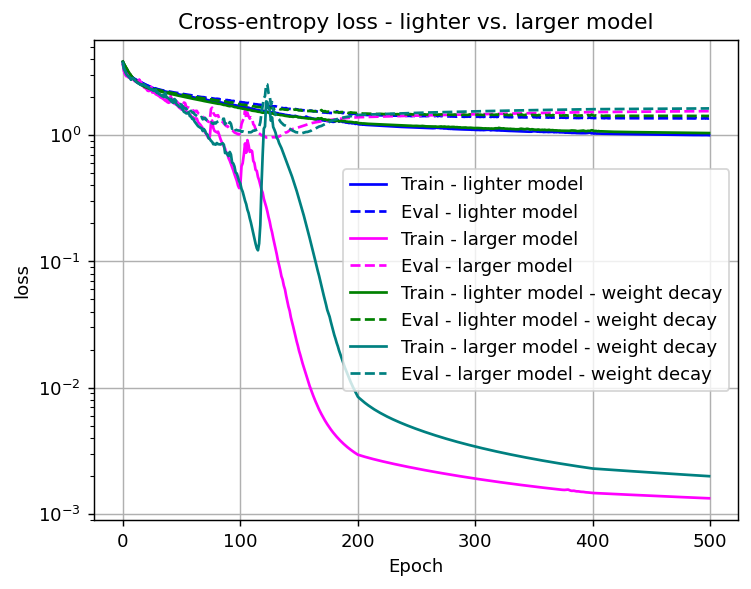

In [10]:
plt.figure(dpi = 130)
plt.title('Cross-entropy loss - lighter vs. larger model')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid()
plt.semilogy(trafo1.epochs, trafo1.losses, color = 'blue', label = 'Train - lighter model')
plt.semilogy(trafo1.epochs, trafo1.losses_eval, '--', color = 'blue', label = 'Eval - lighter model')
plt.semilogy(trafo2.epochs, trafo2.losses, color = 'magenta', label = 'Train - larger model')
plt.semilogy(trafo2.epochs, trafo2.losses_eval, '--', color = 'magenta', label = 'Eval - larger model')
plt.semilogy(trafo1_weight_decay.epochs, trafo1_weight_decay.losses, color = 'green', label = 'Train - lighter model - weight decay')
plt.semilogy(trafo1_weight_decay.epochs, trafo1_weight_decay.losses_eval, '--', color = 'green', label = 'Eval - lighter model - weight decay')
plt.semilogy(trafo2_weight_decay.epochs, trafo2_weight_decay.losses, color = 'teal', label = 'Train - larger model - weight decay')
plt.semilogy(trafo2_weight_decay.epochs, trafo2_weight_decay.losses_eval, '--', color = 'teal', label = 'Eval - larger model - weight decay')
plt.legend()
plt.show()

def translate_string(word, model):
    encoded_input = encode_source(word).unsqueeze(0)
    generated_sequence = model.generate_sequence(encoded_input).cpu().squeeze()[1:-1] # exclude sos at beginning and eos at end

    return decode_source(generated_sequence)

In [ ]:
italian_words = ["gatto", "nave", "croci", "croce", "dito", "stretta", "stretti", "stretto", "strette", "pensate", "lasagna", "passato"]
expected_spanish_cognates_1 = [translate_string(word, trafo1) for word in italian_words]
expected_spanish_cognates_2 = [translate_string(word, trafo2) for word in italian_words]

print("Words in training dataset")
print(f"{'Italian':<15} | {'output light model':<20} | {'output larger model':<20}")
print("-" * 59)

for k in range(len(italian_words)):
    print(f"{italian_words[k]:<15} | {expected_spanish_cognates_1[k]:<20} | {expected_spanish_cognates_2[k]:<20}")

italian_words = ["lutti", "parato", "parata", "parati", "parate", "ottone", "castoro", "matti", "passata", "passate", "ossa"]
expected_spanish_cognates_1 = [translate_string(word, trafo1) for word in italian_words]
expected_spanish_cognates_2 = [translate_string(word, trafo2) for word in italian_words]

print("Words not in training dataset")
print(f"{'Italian':<15} | {'output light model':<20} | {'output larger model':<20}")
print("-" * 59)

for k in range(len(italian_words)):
    print(f"{italian_words[k]:<15} | {expected_spanish_cognates_1[k]:<20} | {expected_spanish_cognates_2[k]:<20}")

Words in training dataset
Italian         | output light model   | output larger model 
-----------------------------------------------------------
gatto           | guevalo              | gato                
nave            | nadas                | nave                
croci           | cofas                | cruces              
croce           | cofedas              | corer               
dito            | decho                | dedo                
stretta         | estrero              | estrecha            
stretti         | esteros              | estrechos           
stretto         | estero               | estrecho            
strette         | ester                | estrechas           
pensate         | pensadas             | pensadas            
lasagna         | lasta                | lasaña              
passato         | pasado               | pasado              
Words not in training dataset
Italian         | output light model   | output larger model 
----------------

In [ ]:

# intermediate size
trafo3 = Transformer(n_layers = 2, d_model = 16, n_heads = 2, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 4, dv = 4, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)

print('trafo3')
print(trafo3.count_parameters_by_module())

# lr = 0.01 seems to work as starting learning rate
print('train trafo3')
trafo3.fit_from_txt("it_es_cognates.txt", n_epochs=500)


trafo3
{'embed': 576, 'pos_encoding': 0, 'encoder': 3376, 'decoder': 4544, 'exit_linear_projection': 612, 'criterion': 0, 'TOTAL': 9108}
train trafo3
Epoch  0 / 500  loss =  3.756373643875122  loss_eval =  3.7493834495544434
Epoch  100 / 500  loss =  0.9662392735481262  loss_eval =  1.3188625574111938
Epoch  200 / 500  loss =  0.4187665581703186  loss_eval =  1.1314005851745605
Epoch  300 / 500  loss =  0.22922669351100922  loss_eval =  1.3424897193908691
Epoch  400 / 500  loss =  0.1307363510131836  loss_eval =  1.5529675483703613


# basically, overfitting
works fine on training dataset but not very well on random words. especially with large model. in some cases the lmodels give ok results for words not in training dataset (such as lutti - luchos). Note that the Spanish must does not have to exist in reality! It is only a hypothetical words obtained by applying the phonetical correspoendence between the two languages

same phenomenon if I change the number of layers n_layers. using weight decay with lambda = 1e-2 does not seem to make much of a difference

need bigger dataset

**regularization: try dropout and change weight decay parameter**